#### <span style="color:cyan">**Imports**</span>

In [4]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd

from util.data_preprocessing import *
from util.pca_plotting import *

from preprocessing.pipelines import build_pca_pipeline

#### <span style="color:cyan">**Data Preprocessing**</span>


geometry labels (8D):
['tlw' 'blw' 'h' 's' 'width_sum' 'width_diff' 'aspect_ratio' 'fill_factor']

geometry_table (8D):
             tlw     blw       h       s  width_sum  width_diff  aspect_ratio  \
run_id                                                                          
run_0001  1.2669  4.7719  0.3148  2.2044     6.0388     -3.5050      0.142805   
run_0002  0.8049  4.2139  0.4596  3.9027     5.0188     -3.4090      0.117765   
run_0003  0.3041  3.1507  0.2406  3.3466     3.4548     -2.8466      0.071894   
run_0004  2.3454  4.7269  0.6228  4.2708     7.0723     -2.3815      0.145827   
run_0005  0.9830  3.6620  0.4859  4.9945     4.6450     -2.6790      0.097287   

          fill_factor  
run_id                 
run_0001     1.369715  
run_0002     0.642991  
run_0003     0.516166  
run_0004     0.827983  
run_0005     0.465012  

absorption data:
wavelength_um    9.901     9.906     9.911     9.916     9.921   ...  \
run_id                                               

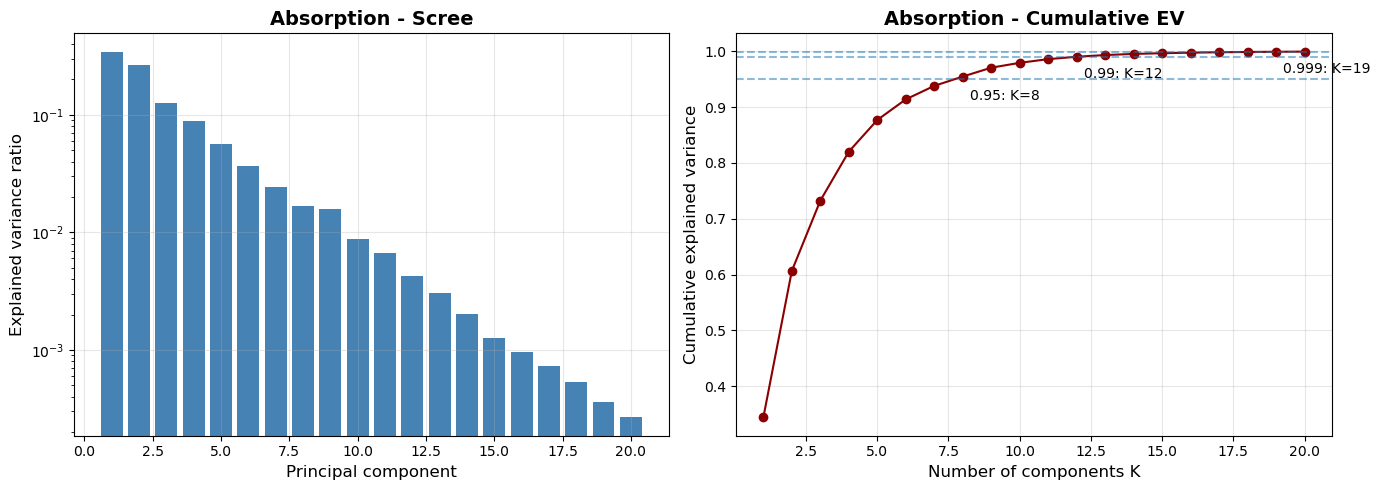

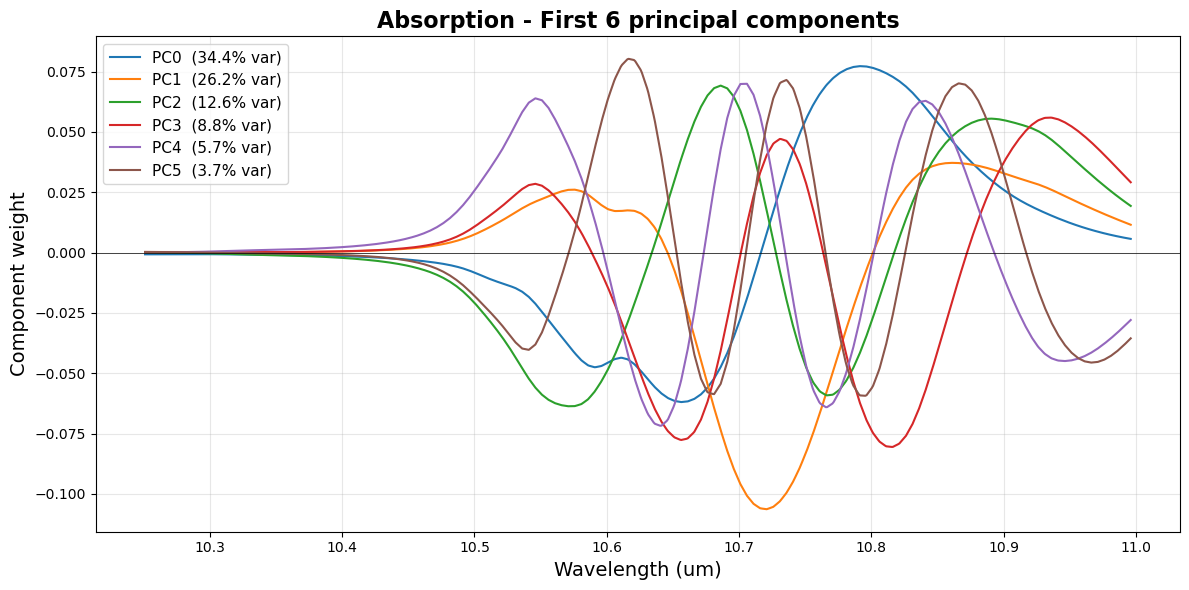

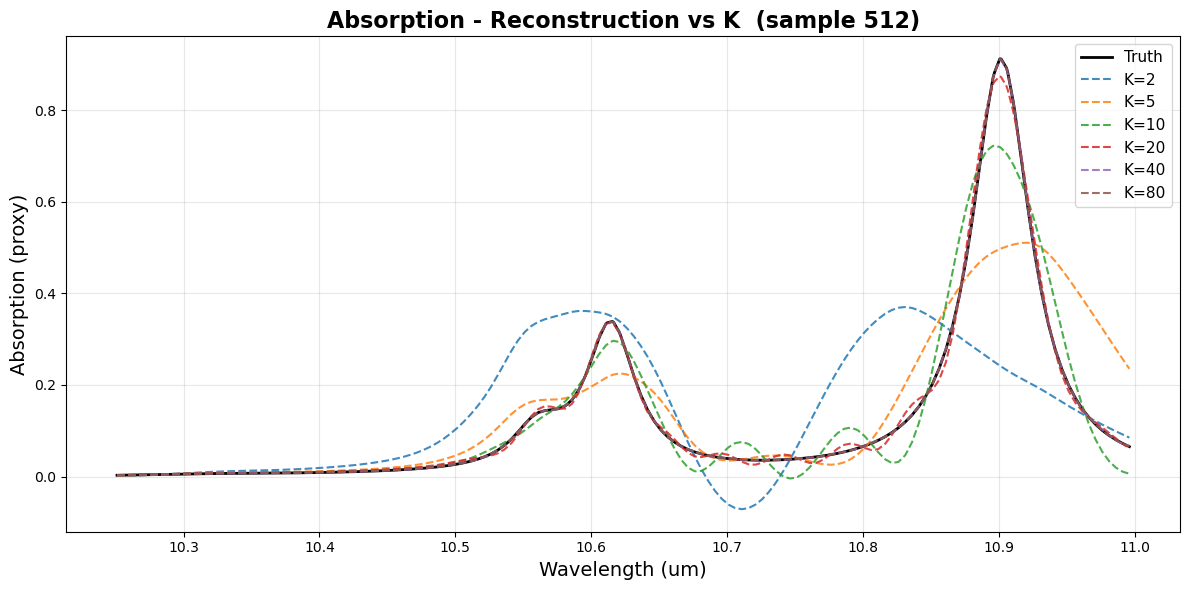

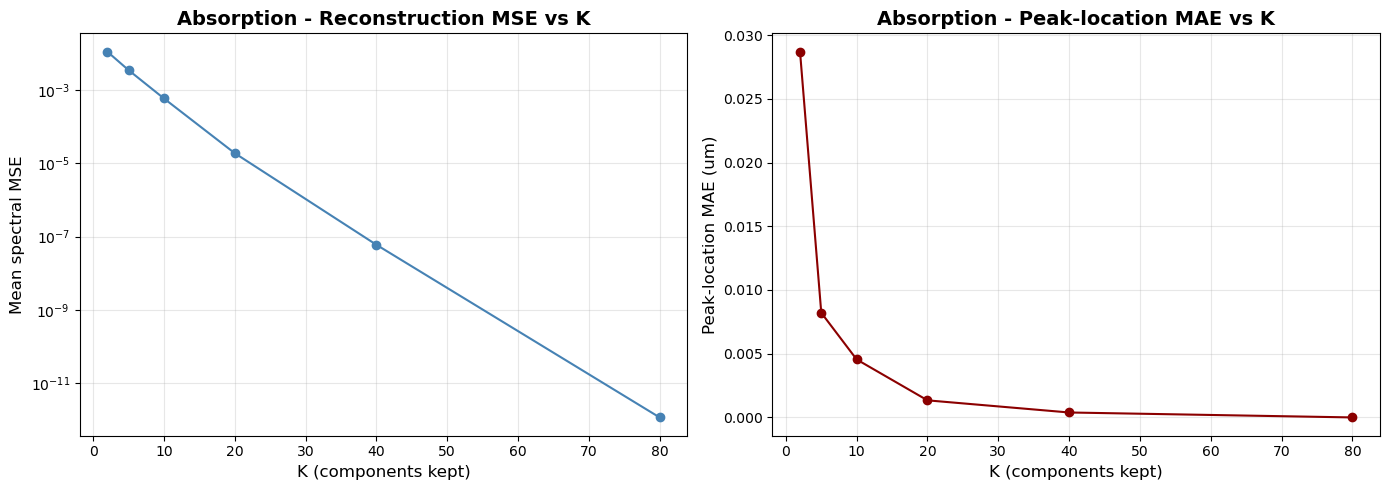

Absorption K-sweep:
  K=  2  MSE=1.123e-02  peak-MAE=0.0287 um
  K=  5  MSE=3.515e-03  peak-MAE=0.0082 um
  K= 10  MSE=5.921e-04  peak-MAE=0.0045 um
  K= 20  MSE=1.898e-05  peak-MAE=0.0013 um
  K= 40  MSE=5.999e-08  peak-MAE=0.0004 um
  K= 80  MSE=1.160e-12  peak-MAE=0.0000 um


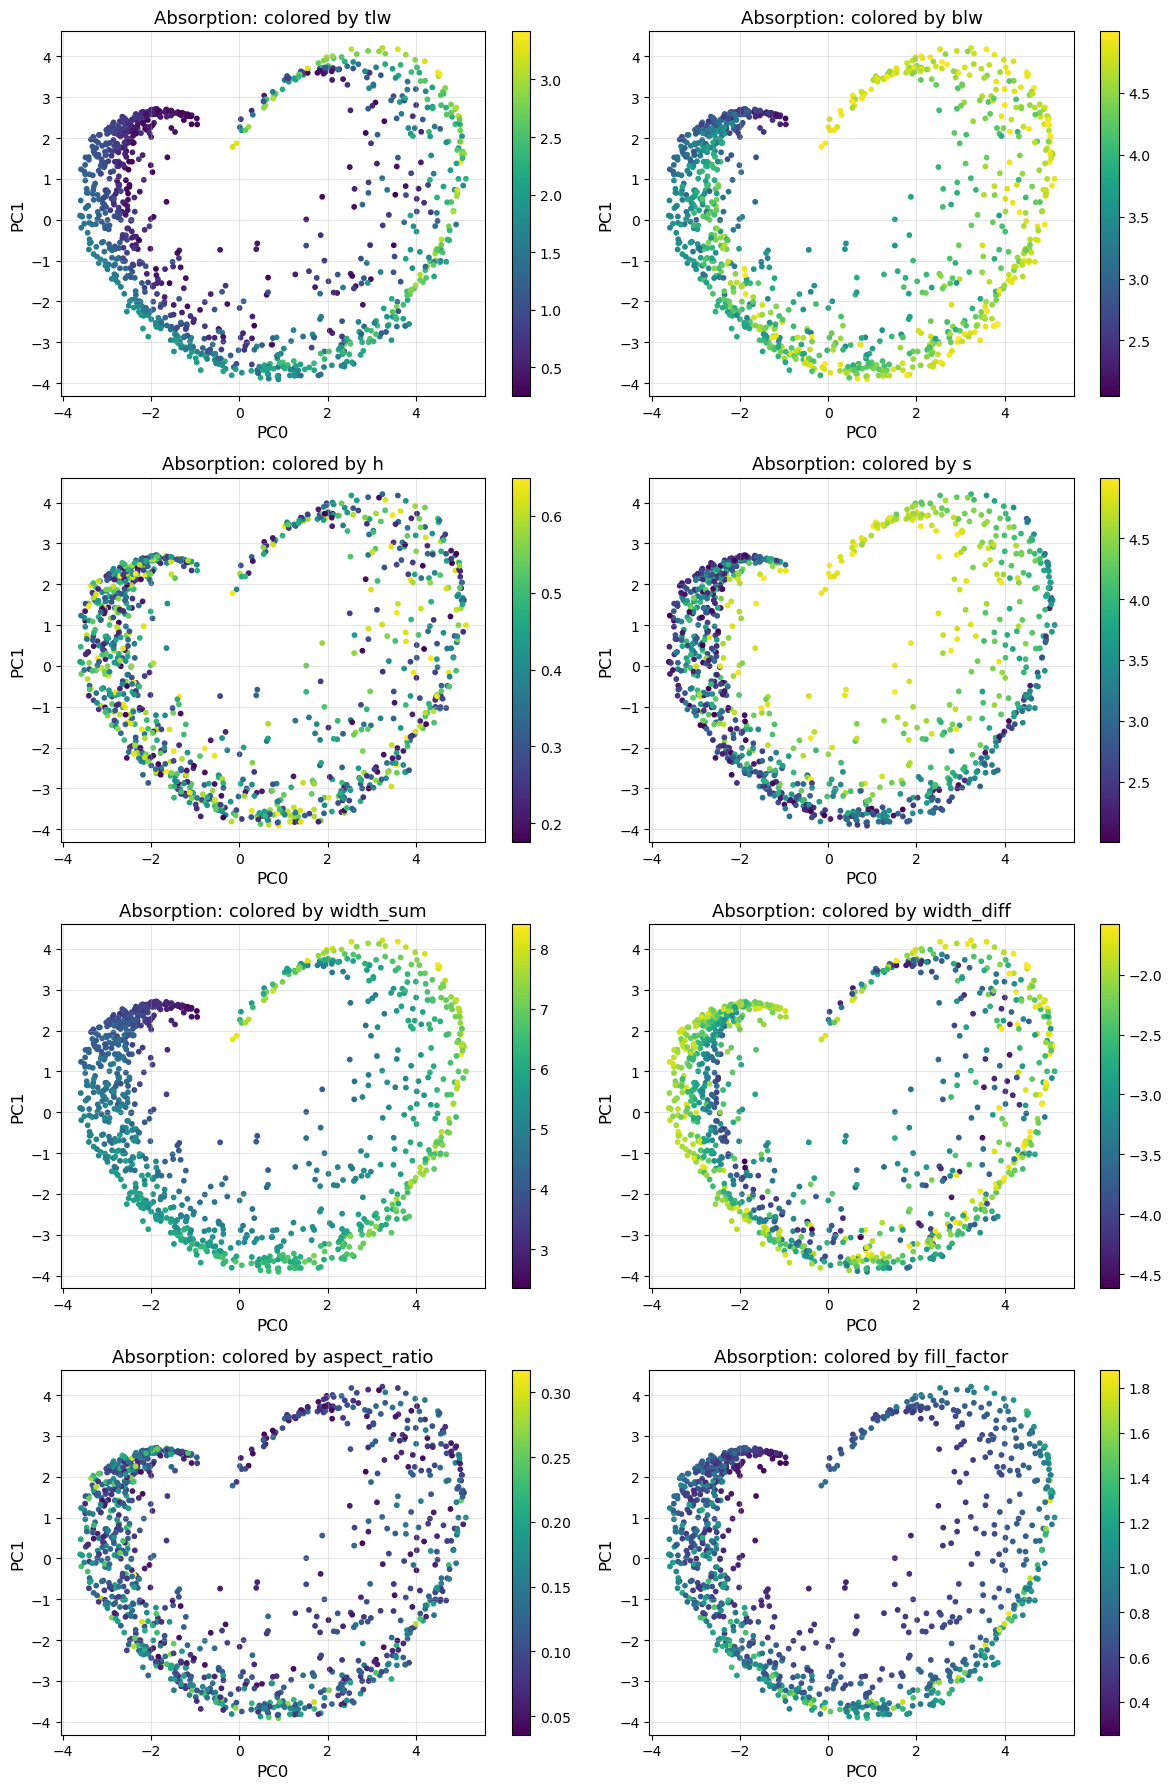

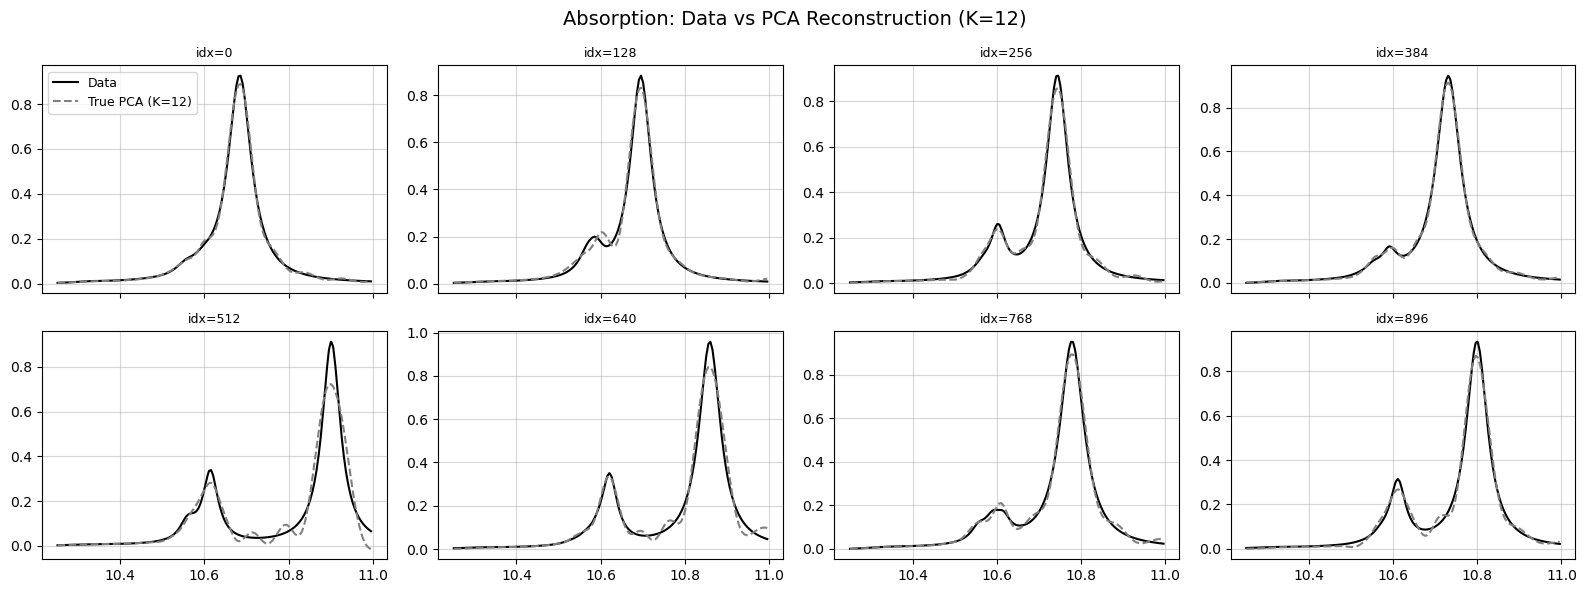

In [6]:
#### DATA PREPROCESSING PIPELINE - PCA FEATURES (8D GEOMETRY) ####
# Config
pd.set_option('display.max_columns', 10)
DATA_PATH = '../data/batch2'
DOMAIN = (10.25, 11.0)
TEST_IDX = np.arange(0, 1024, 128)
INTERP = 4
K = 12
K_SWEEP = [2, 5, 10, 20, 40, 80]
N_PC_SHOW = 6

# Import Data
geom_labels, geom_table, refl_data, abs_data, refl_bg, abs_bg, wl = import_data(DATA_PATH)

# Augment geometry table from 4D -> 8D
geom_table_8d = derive_geometry_features(geom_table)
geom_labels_8d = geom_table_8d.columns.to_numpy()

# Print Data and geometry Table for inspection
print(f'\ngeometry labels (8D):\n{geom_labels_8d}\n')
print(f'geometry_table (8D):\n{geom_table_8d.head()}\n')
print(f'absorption data:\n{abs_data.head()}\n')
print(f'absorption background:\n{abs_bg.head()}\n')

# Build and fit preprocessing pipelines
abs_pipe  = build_pca_pipeline(K, DOMAIN, INTERP, background=abs_bg)
abs_ft_pca  = abs_pipe.fit_transform(abs_data)
abs_pca  = abs_pipe.named_steps['pca'].artifacts_

# Processed spectra (all steps except PCA) — used by exploration plots below
abs_data  = abs_pipe[:-1].fit_transform(abs_data)
wl = abs_data.columns.to_numpy(dtype=float)

# Print feature table for inspection
print(f'Feature table (abs):\n{abs_ft_pca.head()}\n')


#### EXPLORATION PLOTS ####
# 1) Scree / cumulative explained variance
plot_scree(abs_pca, 'Absorption', k_max=20)

# 2) Shapes of the first N principal components
plot_pc_shapes(abs_pca, 'Absorption', N_PC_SHOW)

# 3) Reconstruction fidelity vs K on a single example spectrum
demo_idx = int(TEST_IDX[len(TEST_IDX) // 2])
plot_k_sweep_reconstruction(abs_data, abs_pca, demo_idx, K_SWEEP, 'Absorption')

# 4) Spectral MSE and peak-location MAE vs K (dataset-wide diagnostic)
plot_k_sweep_error(abs_data, abs_pca, K_SWEEP, 'Absorption')

# 5) Latent space scatter: PC0 vs PC1 colored by each geometry parameter (all 8).
plot_latent_colored_by_geom(abs_ft_pca, geom_table_8d, geom_labels_8d, 'Absorption')

# 6) Reconstruction grid: data (target) vs K-component PCA reconstruction
#    for each sample in TEST_IDX. Direct visual check of PCA fidelity.
plot_reconstruction_grid(abs_data, abs_pca, TEST_IDX, 'Absorption')


#### DATA EXPORT ####
# Create export dict (same format as pca_4D.py; geometry_table is now 8D)
pca_ft = {
    "wl": wl,
    "absorption": abs_data,
    "absorption_features": abs_ft_pca,
    "absorption_pca": abs_pca,
    "geometry_labels": geom_labels_8d,
    "geometry_table": geom_table_8d,
    "K": K,
}

data_config = {
    "data_path": DATA_PATH,
    "domain": DOMAIN,
    "interpolation_density": INTERP,
    "K": K,
    "geometry_dim": 8,
    "derived_features": ["width_sum", "width_diff", "aspect_ratio", "fill_factor"],
}
